In [1]:
from RVSS_EOS_Slope import RVSS_EOS_Slope as RVSSEos
from RVSS_EOS_Slope_Ext import RVSS_EOS_Slope_Ext as RVSSEosext
import numpy as np
from matplotlib import pyplot as plt
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov

In [2]:
MN = 939.56
N0 = 0.16
EPSILON = MN*N0

In [3]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16
point_size = 90

In [4]:
EOS_V = RVSSEos(1200,mu_max=2700)
EOS_IV = RVSSEos(1300,mu_max=2700)
EOS_III = RVSSEos(1400,mu_max=2700)
EOS_II = RVSSEos(1500,mu_max=2700)
EOS_I = RVSSEos(1700,mu_max=2700)

matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/RVSS_EOS_Slope.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002761607731865443
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


In [5]:
EOS_V_ext = RVSSEosext(1200,mu_max=2700)
EOS_IV_ext = RVSSEosext(1300,mu_max=2700)
EOS_III_ext = RVSSEosext(1400,mu_max=2700)
EOS_II_ext = RVSSEosext(1500,mu_max=2700)
EOS_I_ext = RVSSEosext(1700,mu_max=2700)

matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/RVSS_EOS_Slope_Ext.py:115: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral_nb = quad(lambda mu_p: 1/(mu_p*cs2_interp(mu_p)),mu_m,mu)
/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/RVSS_EOS_Slope_Ext.py:121: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002761607731865443
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


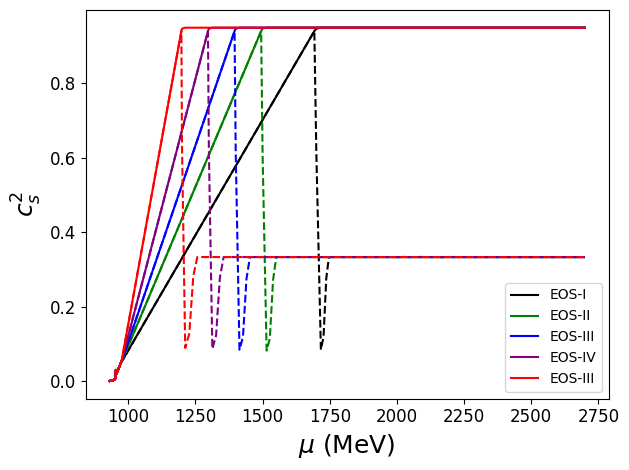

In [6]:

pqcd_cs2_fig,pqcd_cs2_axes = plt.subplots(1)

pqcd_cs2_axes.plot(EOS_I.chem_pot_unified,EOS_III.cs2_unified,color='black',label="EOS-I")
pqcd_cs2_axes.plot(EOS_I_ext.chem_pot_unified,EOS_III_ext.cs2_unified,color='black',linestyle='--')

pqcd_cs2_axes.plot(EOS_II.chem_pot_unified,EOS_II.cs2_unified,color='green',label="EOS-II")
pqcd_cs2_axes.plot(EOS_II_ext.chem_pot_unified,EOS_II_ext.cs2_unified,color='green',linestyle='--')


pqcd_cs2_axes.plot(EOS_III.chem_pot_unified,EOS_III.cs2_unified,color='blue',label="EOS-III")
pqcd_cs2_axes.plot(EOS_III_ext.chem_pot_unified,EOS_III_ext.cs2_unified,color = 'blue', linestyle='--',)

pqcd_cs2_axes.plot(EOS_IV.chem_pot_unified,EOS_IV.cs2_unified,color='purple',label="EOS-IV")
pqcd_cs2_axes.plot(EOS_IV_ext.chem_pot_unified,EOS_IV_ext.cs2_unified,color = 'purple', linestyle='--',)

pqcd_cs2_axes.plot(EOS_V.chem_pot_unified,EOS_V.cs2_unified,color='red',label="EOS-III")
pqcd_cs2_axes.plot(EOS_V_ext.chem_pot_unified,EOS_V_ext.cs2_unified,color = 'red', linestyle='--',)
pqcd_cs2_axes.legend()


pqcd_cs2_axes.set_xlabel(r"$\mu\text{ (MeV)}$",fontsize=axes_label_fontsize)
pqcd_cs2_axes.set_ylabel(r"$c_s^2$",fontsize=axes_label_fontsize)

pqcd_cs2_axes.tick_params(labelsize=tick_label_fontsize)
pqcd_cs2_fig.tight_layout()

pqcd_cs2_fig.savefig('./Figures/Final_Paper_Figs/cs2_vs_mu_extension.pdf',format='pdf',dpi = 300)

First we need to determine $\mu_{\text{TOV}}$ for the TOV configuration of each star. 

In [7]:
solver_V = tov(EPSILON,lambda p: EOS_V.eos_interp(p*EPSILON)/EPSILON,lambda p: EOS_V.nb_interp(p))
solver_IV = tov(EPSILON,lambda p: EOS_IV.eos_interp(p*EPSILON)/EPSILON,lambda p: EOS_IV.nb_interp(p))
solver_III = tov(EPSILON,lambda p: EOS_III.eos_interp(p*EPSILON)/EPSILON,lambda p: EOS_III.nb_interp(p))
solver_II = tov(EPSILON,lambda p: EOS_II.eos_interp(p*EPSILON)/EPSILON,lambda p: EOS_II.nb_interp(p))
solver_I = tov(EPSILON,lambda p: EOS_I.eos_interp(p*EPSILON)/EPSILON,lambda p: EOS_I.nb_interp(p))

In [8]:
solver_Vext = tov(EPSILON,lambda p: EOS_V_ext.eos_interp(p*EPSILON)/EPSILON,lambda p: EOS_V_ext.nb_interp(p))
solver_IVext = tov(EPSILON,lambda p: EOS_IV_ext.eos_interp(p*EPSILON)/EPSILON,lambda p: EOS_IV_ext.nb_interp(p))
solver_IIIext = tov(EPSILON,lambda p: EOS_III_ext.eos_interp(p*EPSILON)/EPSILON,lambda p: EOS_III_ext.nb_interp(p))
solver_IIext = tov(EPSILON,lambda p: EOS_II_ext.eos_interp(p*EPSILON)/EPSILON,lambda p: EOS_II_ext.nb_interp(p))
solver_Iext = tov(EPSILON,lambda p: EOS_I_ext.eos_interp(p*EPSILON)/EPSILON,lambda p: EOS_I_ext.nb_interp(p))

In [9]:
npoints = 100

central_pressures = np.logspace(-2,1,npoints)
solutions_I = []
solutions_II = []
solutions_III = []
solutions_IV = []
solutions_V = []

for i,pc in enumerate(central_pressures):
    sol_I = solver_I.solve(pc,dr=0.001,rmax=30,dr_max=0.01)
    sol_II = solver_II.solve(pc,dr=0.001,rmax=30,dr_max=0.01)
    sol_III = solver_III.solve(pc,dr=0.001,rmax=30,dr_max=0.01)
    sol_IV = solver_IV.solve(pc,dr=0.001,rmax=30,dr_max=0.01)
    sol_V = solver_V.solve(pc,dr=0.001,dr_max=0.01,rmax=30)

    solutions_I.append(sol_I)
    solutions_II.append(sol_II)
    solutions_III.append(sol_III)
    solutions_IV.append(sol_IV)
    solutions_V.append(sol_V)

    print(i,sol_V.y[1,-1],sol_V.t[-1])




0 0.15861831931522336 22.551344022337812
1 0.16565326920459916 21.451571685543108
2 0.1730530048922313 20.50752184633728
3 0.18082691197389134 19.67694971020213
4 0.188989421658314 18.94980328915431
5 0.19755350471594038 18.310762655929263
6 0.2065328975598854 17.74126598134845
7 0.21594500061212804 17.247088627930065
8 0.22580668072779553 16.797552457346853
9 0.23613447958377665 16.3913521205473
10 0.24694501900100876 16.030293178349144
11 0.25824040732851333 15.701961723170363
12 0.27003943434712674 15.41763507177933
13 0.28244826090304753 15.147066369564413
14 0.2955487821608056 14.901745883805809
15 0.309407109378945 14.687083891462473
16 0.32408960912489554 14.48771597027656
17 0.33966154517944847 14.300657493541816
18 0.3561873464169271 14.132219752852912
19 0.37373062066012 13.982094511902524
20 0.3923543082340215 13.857788843871628
21 0.41212070697261916 13.732301061832683
22 0.43309140789201656 13.628458266378972
23 0.4553271505800732 13.537332375694138
24 0.47888764710770787 

In [10]:
npoints = 100

central_pressures = np.logspace(-2,1,npoints)
solutions_Vext = []
solutions_IVext = []
solutions_IIIext = []
solutions_IIext = []
solutions_Iext = []

for i,pc in enumerate(central_pressures):
    sol_Iext = solver_Iext.solve(pc,dr=0.001,rmax=30,dr_max=0.01)
    sol_IIext = solver_IIext.solve(pc,dr=0.001,rmax=30,dr_max=0.01)
    sol_IIIext = solver_IIIext.solve(pc,dr=0.001,rmax=30,dr_max=0.01)
    sol_IVext = solver_IVext.solve(pc,dr=0.001,rmax=30,dr_max=0.01)
    sol_Vext = solver_Vext.solve(pc,dr=0.001,dr_max=0.01,rmax=30)

    solutions_Iext.append(sol_Iext)
    solutions_IIext.append(sol_IIext)
    solutions_IIIext.append(sol_IIIext)
    solutions_IVext.append(sol_IVext)
    solutions_Vext.append(sol_Vext)

    print(i,sol_Vext.y[1,-1],sol_Vext.t[-1])

0 0.15861831931522336 22.551344022337812
1 0.16565326920459916 21.451571685543108
2 0.1730530048922313 20.50752184633728
3 0.18082691197389134 19.67694971020213
4 0.188989421658314 18.94980328915431
5 0.19755350471594038 18.310762655929263
6 0.2065328975598854 17.74126598134845
7 0.21594500061212804 17.247088627930065
8 0.22580668072779553 16.797552457346853
9 0.23613447958377665 16.3913521205473
10 0.24694501900100876 16.030293178349144
11 0.25824040732851333 15.701961723170363
12 0.27003943434712674 15.41763507177933
13 0.28244826090304753 15.147066369564413
14 0.2955487821608056 14.901745883805809
15 0.309407109378945 14.687083891462473
16 0.32408960912489554 14.48771597027656
17 0.33966154517944847 14.300657493541816
18 0.3561873464169271 14.132219752852912
19 0.37373062066012 13.982094511902524
20 0.3923543082340215 13.857788843871628
21 0.41212070697261916 13.732301061832683
22 0.43309140789201656 13.628458266378972
23 0.4553271505800732 13.537332375694138
24 0.47888764710770787 

In [11]:
Mg_I = [sol.y[1,-1] for sol in solutions_I]
Mg_II = [sol.y[1,-1] for sol in solutions_II]
Mg_III = [sol.y[1,-1] for sol in solutions_III]
Mg_IV = [sol.y[1,-1] for sol in solutions_IV]
Mg_V = [sol.y[1,-1] for sol in solutions_V]

Mg_Iext = [sol.y[1,-1] for sol in solutions_Iext]
Mg_IIext = [sol.y[1,-1] for sol in solutions_IIext]
Mg_IIIext = [sol.y[1,-1] for sol in solutions_IIIext]
Mg_IVext = [sol.y[1,-1] for sol in solutions_IVext]
Mg_Vext = [sol.y[1,-1] for sol in solutions_Vext]


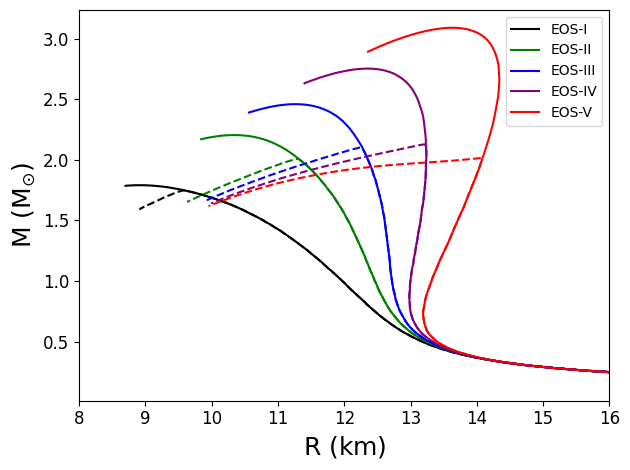

In [13]:

mvrext_fig,mvrext_axes = plt.subplots(1)

mvrext_axes .plot([sol.t[-1] for sol in solutions_I],[sol.y[1,-1] for sol in solutions_I],color = 'black',label='EOS-I')
mvrext_axes .plot([sol.t[-1] for sol in solutions_II],[sol.y[1,-1] for sol in solutions_II],color = 'green',label='EOS-II')
mvrext_axes .plot([sol.t[-1] for sol in solutions_III],[sol.y[1,-1] for sol in solutions_III],color = 'blue',label='EOS-III')
mvrext_axes .plot([sol.t[-1] for sol in solutions_IV],[sol.y[1,-1] for sol in solutions_IV],color = 'purple',label='EOS-IV')
mvrext_axes .plot([sol.t[-1] for sol in solutions_V],[sol.y[1,-1] for sol in solutions_V],color = 'red',label='EOS-V')

mvrext_axes .plot([sol.t[-1] for sol in solutions_Iext],[sol.y[1,-1] for sol in solutions_Iext],color = 'black',linestyle='--')
mvrext_axes .plot([sol.t[-1] for sol in solutions_IIext],[sol.y[1,-1] for sol in solutions_IIext],color = 'green',linestyle='--')
mvrext_axes .plot([sol.t[-1] for sol in solutions_IIIext],[sol.y[1,-1] for sol in solutions_IIIext],color = 'blue',linestyle='--')
mvrext_axes .plot([sol.t[-1] for sol in solutions_IVext],[sol.y[1,-1] for sol in solutions_IVext],color = 'purple',linestyle='--')
mvrext_axes .plot([sol.t[-1] for sol in solutions_Vext],[sol.y[1,-1] for sol in solutions_Vext],color = 'red',linestyle='--')

mvrext_axes.set_xlim([8,16])
mvrext_axes.set_ylabel(r"$\text{M (M}_{\odot})$",fontsize=axes_label_fontsize)
mvrext_axes.set_xlabel(r"$\text{R (km)}$",fontsize=axes_label_fontsize)
mvrext_axes.tick_params(labelsize=tick_label_fontsize)
mvrext_axes.legend()
mvrext_fig.tight_layout()

mvrext_fig.savefig('./Figures/Final_Paper_Figs/MVR_Extension.pdf',format='pdf',dpi=300)

In [14]:
Ptov_I = central_pressures[np.argmax(Mg_I)]*EPSILON
Ptov_II = central_pressures[np.argmax(Mg_II)]*EPSILON
Ptov_III = central_pressures[np.argmax(Mg_III)]*EPSILON
Ptov_IV = central_pressures[np.argmax(Mg_IV)]*EPSILON
Ptov_V = central_pressures[np.argmax(Mg_V)]*EPSILON

EpsTov_I = EOS_I.eos_interp(Ptov_I)
EpsTov_II = EOS_II.eos_interp(Ptov_II)
EpsTov_III = EOS_III.eos_interp(Ptov_III)
EpsTov_IV = EOS_IV.eos_interp(Ptov_IV)
EpsTov_V = EOS_V.eos_interp(Ptov_V)

nTov_I = EOS_I.nb_interp(Ptov_I)
nTov_II = EOS_II.nb_interp(Ptov_II)
nTov_III = EOS_III.nb_interp(Ptov_III)
nTov_IV = EOS_IV.nb_interp(Ptov_IV)
nTov_V = EOS_V.nb_interp(Ptov_V)

muTov_I = (Ptov_I + EpsTov_I)/(nTov_I)
muTov_II = (Ptov_II + EpsTov_II)/(nTov_II)
muTov_III = (Ptov_III + EpsTov_III)/(nTov_III)
muTov_IV = (Ptov_IV + EpsTov_IV)/(nTov_IV)
muTov_V = (Ptov_V + EpsTov_V)/(nTov_V)

print('P_TOV EOS V', central_pressures[np.argmax(Mg_V)]*EPSILON)
print('P_TOV EOS IV', central_pressures[np.argmax(Mg_IV)]*EPSILON)
print('P_TOV EOS III', central_pressures[np.argmax(Mg_III)]*EPSILON)
print('P_TOV EOS II', central_pressures[np.argmax(Mg_II)]*EPSILON)
print('P_TOV EOS I', central_pressures[np.argmax(Mg_I)]*EPSILON)

print('EPS_TOV_I',EpsTov_I)
print('EPS_TOV_II',EpsTov_II)
print('EPS_TOV_III',EpsTov_III)
print('EPS_TOV_IV',EpsTov_IV)
print('EPS_TOV_V',EpsTov_V)

print('nTOV_I',nTov_I)
print('nTOV_II',nTov_II)
print('nTOV_III',nTov_III)
print('nTOV_IV',nTov_IV)
print('nTOV_V',nTov_V)

print("mu_TOV_I",muTov_I)
print("mu_TOV_II",muTov_II)
print("mu_TOV_III",muTov_III)
print("mu_TOV_IV",muTov_IV)
print("mu_TOV_V",muTov_V)




P_TOV EOS V 492.26166583574377
P_TOV EOS IV 606.8831896779164
P_TOV EOS III 748.1939616166209
P_TOV EOS II 922.4084860492934
P_TOV EOS I 1219.3697334028136
EPS_TOV_I 2163.490981003481
EPS_TOV_II 1511.8684267379567
EPS_TOV_III 1210.4263562265714
EPS_TOV_IV 969.1458859639677
EPS_TOV_V 776.3497702930176
nTOV_I 1.5826173315531324
nTOV_II 1.1143003164917875
nTOV_III 0.9066687041639392
nTOV_IV 0.7357546360480766
nTOV_V 0.595399471205122
mu_TOV_I 2137.510216121833
mu_TOV_II 2184.5788579251393
mu_TOV_III 2160.238143048384
mu_TOV_IV 2142.0579612071942
mu_TOV_V 2130.6895579887237


In [15]:
Ptov_Iext = central_pressures[np.argmax(Mg_Iext)] * EPSILON
Ptov_IIext = central_pressures[np.argmax(Mg_IIext)] * EPSILON
Ptov_IIIext = central_pressures[np.argmax(Mg_IIIext)] * EPSILON
Ptov_IVext = central_pressures[np.argmax(Mg_IVext)] * EPSILON
Ptov_Vext = central_pressures[np.argmax(Mg_Vext)] * EPSILON

EpsTov_Iext = EOS_I_ext.eos_interp(Ptov_Iext)
EpsTov_IIext = EOS_II_ext.eos_interp(Ptov_IIext)
EpsTov_IIIext = EOS_III_ext.eos_interp(Ptov_IIIext)
EpsTov_IVext = EOS_IV_ext.eos_interp(Ptov_IVext)
EpsTov_Vext = EOS_V_ext.eos_interp(Ptov_Vext)

nTov_Iext = EOS_I_ext.nb_interp(Ptov_Iext)
nTov_IIext = EOS_II_ext.nb_interp(Ptov_IIext)
nTov_IIIext = EOS_III_ext.nb_interp(Ptov_IIIext)
nTov_IVext = EOS_IV_ext.nb_interp(Ptov_IVext)
nTov_Vext = EOS_V_ext.nb_interp(Ptov_Vext)

muTov_Iext = (Ptov_Iext + EpsTov_Iext) / nTov_Iext
muTov_IIext = (Ptov_IIext + EpsTov_IIext) / nTov_IIext
muTov_IIIext = (Ptov_IIIext + EpsTov_IIIext) / nTov_IIIext
muTov_IVext = (Ptov_IVext + EpsTov_IVext) / nTov_IVext
muTov_Vext = (Ptov_Vext + EpsTov_Vext) / nTov_Vext

print('P_TOV EOS V', central_pressures[np.argmax(Mg_Vext)] * EPSILON)
print('P_TOV EOS IV', central_pressures[np.argmax(Mg_IVext)] * EPSILON)
print('P_TOV EOS III', central_pressures[np.argmax(Mg_IIIext)] * EPSILON)
print('P_TOV EOS II', central_pressures[np.argmax(Mg_IIext)] * EPSILON)
print('P_TOV EOS I', central_pressures[np.argmax(Mg_Iext)] * EPSILON)

print('EPS_TOV_Iext', EpsTov_Iext)
print('EPS_TOV_IIext', EpsTov_IIext)
print('EPS_TOV_IIIext', EpsTov_IIIext)
print('EPS_TOV_IVext', EpsTov_IVext)
print('EPS_TOV_Vext', EpsTov_Vext)

print('nTOV_Iext', nTov_Iext/N0)
print('nTOV_IIext', nTov_IIext/N0)
print('nTOV_IIIext', nTov_IIIext/N0)
print('nTOV_IVext', nTov_IVext/N0)
print('nTOV_Vext', nTov_Vext/N0)

print("mu_TOV_Iext", muTov_Iext)
print("mu_TOV_IIext", muTov_IIext)
print("mu_TOV_IIIext", muTov_IIIext)
print("mu_TOV_IVext", muTov_IVext)
print("mu_TOV_Vext", muTov_Vext)

P_TOV EOS V 74.81939616166206
P_TOV EOS IV 130.74901966393034
P_TOV EOS III 213.0883239231214
P_TOV EOS II 302.0471935824026
P_TOV EOS I 650.7409518807036
EPS_TOV_Iext 2449.4055963130318
EPS_TOV_IIext 1157.921597525174
EPS_TOV_IIIext 1084.2891744486863
EPS_TOV_IVext 790.3900718098485
EPS_TOV_Vext 570.5498309698103
nTOV_Iext 11.174968546707712
nTOV_IIext 5.996433771925391
nTOV_IIIext 5.640490443521936
nTOV_IVext 4.327268125733806
nTOV_Vext 3.2885441781914313
mu_TOV_Iext 1733.8676028684872
mu_TOV_IIext 1521.7052820867689
mu_TOV_IIIext 1437.5716874294997
mu_TOV_IVext 1330.4281487606781
mu_TOV_Vext 1226.5481170424778


In [16]:
ntov_Iext = EOS_I_ext.nb_interp(central_pressures[np.argmax(Mg_Iext)] * EPSILON)
ntov_IIext = EOS_II_ext.nb_interp(central_pressures[np.argmax(Mg_IIext)] * EPSILON)
ntov_IIIext = EOS_III_ext.nb_interp(central_pressures[np.argmax(Mg_IIIext)] * EPSILON)
ntov_IVext = EOS_IV_ext.nb_interp(central_pressures[np.argmax(Mg_IVext)] * EPSILON)
ntov_Vext = EOS_V_ext.nb_interp(central_pressures[np.argmax(Mg_Vext)] * EPSILON)

nmax_Iext = ntov_Iext*3
nmax_IIext = ntov_IIext*3
nmax_IIIext = ntov_IIIext*3
nmax_IVext = ntov_IVext*3
nmax_Vext = ntov_Vext*3

Epsmax_Iext = EOS_I_ext.eden_nb(nmax_Iext)
Epsmax_IIext = EOS_II_ext.eden_nb(nmax_IIext)
Epsmax_IIIext = EOS_III_ext.eden_nb(nmax_IIIext)
Epsmax_IVext = EOS_IV_ext.eden_nb(nmax_IVext)
Epsmax_Vext = EOS_V_ext.eden_nb(nmax_Vext)

Pmax_Iext = EOS_I_ext.press_nb(nmax_Iext)
Pmax_IIext = EOS_II_ext.press_nb(nmax_IIext)
Pmax_IIIext = EOS_III_ext.press_nb(nmax_IIIext)
Pmax_IVext = EOS_IV_ext.press_nb(nmax_IVext)
Pmax_Vext = EOS_V_ext.press_nb(nmax_Vext)



mumax_Iext = (Pmax_Iext + Epsmax_Iext) / nmax_Iext
mumax_IIext = (Pmax_IIext + Epsmax_IIext) / nmax_IIext
mumax_IIIext = (Pmax_IIIext + Epsmax_IIIext) / nmax_IIIext
mumax_IVext = (Pmax_IVext + Epsmax_IVext) / nmax_IVext
mumax_Vext = (Pmax_Vext + Epsmax_Vext) / nmax_Vext

print(mumax_Iext)
print(mumax_IIext)
print(mumax_IIIext)
print(mumax_IVext)
print(mumax_Vext)

2499.827038945416
2091.149806211443
2072.8892544545115
1914.8941271627607
1757.6876957309473


In [17]:
ntov_II = EOS_II.nb_interp(central_pressures[np.argmax(Mg_II)] * EPSILON)
ntov_III = EOS_III.nb_interp(central_pressures[np.argmax(Mg_III)] * EPSILON)
ntov_IV = EOS_IV.nb_interp(central_pressures[np.argmax(Mg_IV)] * EPSILON)
ntov_V = EOS_V.nb_interp(central_pressures[np.argmax(Mg_V)] * EPSILON)


nmax_II = 4.5*N0
nmax_III = 3.5*N0
nmax_IV = 2.5*N0
nmax_V = 2*N0

Epsmax_II = EOS_II.eden_nb(nmax_II)
Epsmax_III = EOS_III.eden_nb(nmax_III)
Epsmax_IV = EOS_IV.eden_nb(nmax_IV)
Epsmax_V = EOS_V.eden_nb(nmax_V)

Pmax_II = EOS_II.press_nb(nmax_II)
Pmax_III = EOS_III.press_nb(nmax_III)
Pmax_IV = EOS_IV.press_nb(nmax_IV)
Pmax_V = EOS_V.press_nb(nmax_V)

mumax_II = (Pmax_II + Epsmax_II) / nmax_II
mumax_III = (Pmax_III + Epsmax_III) / nmax_III
mumax_IV = (Pmax_IV + Epsmax_IV) / nmax_IV
mumax_V = (Pmax_V + Epsmax_V) / nmax_V



In [25]:
muTOV = [muTov_I,muTov_II,muTov_III,muTov_IV,muTov_V]
PTOV = [Ptov_I,Ptov_II,Ptov_III,Ptov_IV,Ptov_V]

muTOV_ext = [muTov_Iext,muTov_IIext,muTov_IIIext,muTov_IVext,muTov_Vext]
PTOV_ext = [Ptov_Iext,Ptov_IIext,Ptov_IIIext,Ptov_IVext,Ptov_Vext]

muMAX_ext = [mumax_Iext,mumax_IIext,mumax_IIIext,mumax_IVext,mumax_Vext,]
P_maxext = [Pmax_Iext,Pmax_IIext,Pmax_IIIext,Pmax_IVext,Pmax_Vext]

muMAX = [mumax_II,mumax_III,mumax_IV,mumax_V]
P_max = [Pmax_II,Pmax_III,Pmax_IV,Pmax_V]

In [28]:
print(muMAX)

[1445.5397345170632, 1367.9844457874365, 1213.392040730377, 1181.9720875172547]


In [19]:
c1 = 0.9008
d1 = 0.5034
d2 = 1.452
nu_1 = 0.3553
nu_2 = 0.9101


hc = 197

In [20]:
def P_SB(mu_b):
    return (3/(4*np.pi**2))*(mu_b/3)**(4.0)

In [21]:
def a(X):
    return d1*X**(-1*nu_1)
def b(X):
    return d2**X**(-1*nu_2)

In [22]:
def Pqcd(mu_b,X):
    return P_SB(mu_b)*(c1 - (a(X))/((mu_b/1000) - b(X)))

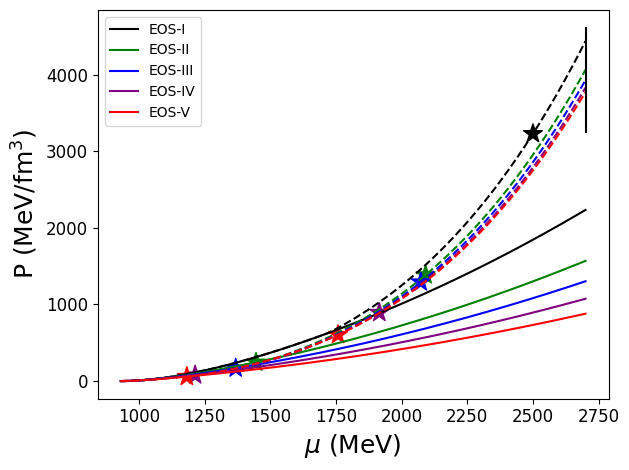

In [33]:
Press_vs_mu_fig,Press_vs_mu_axes = plt.subplots(1)


Press_vs_mu_axes.scatter(muMAX_ext,P_maxext,s=200,color=["black","green","blue","purple","red"],marker="*")
Press_vs_mu_axes.scatter(muMAX,P_max,s=200,color=["green","blue","purple","red"],marker="*")


Press_vs_mu_axes.plot(EOS_I.chem_pot_unified,EOS_I.P_unified,color='black',label="EOS-I")
Press_vs_mu_axes.plot(EOS_II.chem_pot_unified,EOS_II.P_unified,color='green',label="EOS-II")
Press_vs_mu_axes.plot(EOS_III.chem_pot_unified,EOS_III.P_unified,color='blue',label="EOS-III")
Press_vs_mu_axes.plot(EOS_IV.chem_pot_unified,EOS_IV.P_unified,color='purple',label="EOS-IV")
Press_vs_mu_axes.plot(EOS_V.chem_pot_unified,EOS_V.P_unified,color='red',label="EOS-V")

Press_vs_mu_axes.plot(EOS_I_ext.chem_pot_unified,EOS_I_ext.P_unified,color='black',linestyle='--')
Press_vs_mu_axes.plot(EOS_II_ext.chem_pot_unified,EOS_II_ext.P_unified,color='green',linestyle='--')
Press_vs_mu_axes.plot(EOS_III_ext.chem_pot_unified,EOS_III_ext.P_unified,color='blue',linestyle='--')
Press_vs_mu_axes.plot(EOS_IV_ext.chem_pot_unified,EOS_IV_ext.P_unified,color='purple',linestyle='--')
Press_vs_mu_axes.plot(EOS_V_ext.chem_pot_unified,EOS_V_ext.P_unified,color='red',linestyle='--')
Press_vs_mu_axes.plot([2700,2700],[Pqcd(2700,1)/(hc**3),Pqcd(2700,4)/(hc**3)],color='black')
Press_vs_mu_axes.set_xlabel(r"$\mu \text{ (MeV)}$",fontsize=axes_label_fontsize)
Press_vs_mu_axes.set_ylabel(r"$\text{P }\text{(MeV}/\text{fm}^3)$",fontsize=axes_label_fontsize)
Press_vs_mu_axes.tick_params(labelsize=tick_label_fontsize)
Press_vs_mu_axes.legend()

Press_vs_mu_fig.tight_layout()

Press_vs_mu_fig.savefig('./Figures/Final_Paper_Figs/P_vs_mu.pdf',format='pdf',dpi=300)




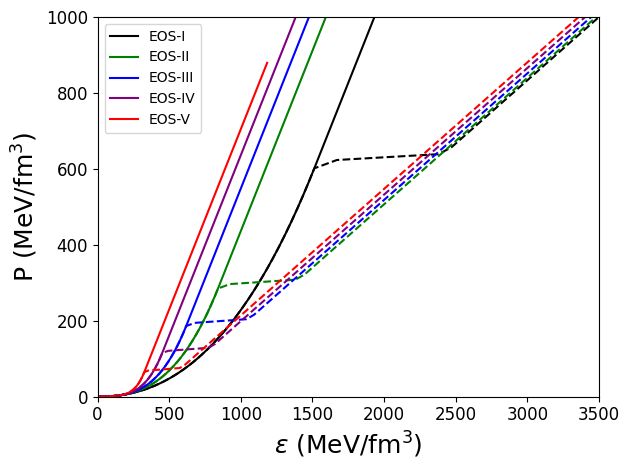

In [42]:
eos_fig,eos_axes = plt.subplots(1)




eos_axes.plot(EOS_I.E_unified,EOS_I.P_unified,color='black',label="EOS-I")
eos_axes.plot(EOS_II.E_unified,EOS_II.P_unified,color='green',label="EOS-II")
eos_axes.plot(EOS_III.E_unified,EOS_III.P_unified,color='blue',label="EOS-III")
eos_axes.plot(EOS_IV.E_unified,EOS_IV.P_unified,color='purple',label="EOS-IV")
eos_axes.plot(EOS_V.E_unified,EOS_V.P_unified,color='red',label="EOS-V")

eos_axes.plot(EOS_I_ext.E_unified,EOS_I_ext.P_unified,color='black',linestyle='--')
eos_axes.plot(EOS_II_ext.E_unified,EOS_II_ext.P_unified,color='green',linestyle='--')
eos_axes.plot(EOS_III_ext.E_unified,EOS_III_ext.P_unified,color='blue',linestyle='--')
eos_axes.plot(EOS_IV_ext.E_unified,EOS_IV_ext.P_unified,color='purple',linestyle='--')
eos_axes.plot(EOS_V_ext.E_unified,EOS_V_ext.P_unified,color='red',linestyle='--')
eos_axes.set_xlabel(r"$\varepsilon \text{ (MeV}/\text{fm}^3)$",fontsize=axes_label_fontsize)
eos_axes.set_ylabel(r"$\text{P } \text{(MeV}/\text{fm}^3)$",fontsize=axes_label_fontsize)
eos_axes.tick_params(labelsize=tick_label_fontsize)
eos_axes.legend()
eos_axes.set_xlim([0,3500])
eos_axes.set_ylim([0,1000])

eos_fig.tight_layout()

eos_fig.savefig('./Figures/Final_Paper_Figs/eos_extended.pdf',format='pdf',dpi=300)
